
# Q3 - Temperature vs Monthly Electricity Consumption (Loay)

This analysis studies the relationship between temperature changes and monthly electricity consumption across cities using the provided environmental dataset.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('environment_data.csv')

df.head()


,City,Date,PM2.5,PM10,O3,NO2,CO,SO2,Green_Space,Temperature_mean,Temperature_max,Humidity,Wind_speed,Pressure,Electricity Consumption,isWeekend,Season
0,Cairo,2023-01-01,36.337500,60.341667,33.333333,36.100000,337.416667,34.795833,53,15.888889,20.0,75.333333,8.511111,1007.247111,1.116235e+10,0,Winter
1,Cairo,2023-01-02,49.379167,78.937500,18.625000,46.704167,442.000000,55.141667,53,16.044444,21.0,70.844444,7.888889,1006.393556,1.116235e+10,0,Winter
2,Cairo,2023-01-03,34.066667,51.825000,24.583333,44.612500,387.041667,48.670833,53,15.288889,19.0,75.911111,6.644444,1006.458667,1.116235e+10,0,Winter
3,Cairo,2023-01-04,30.737500,43.029167,38.958333,37.420833,322.166667,42.025000,53,15.777778,19.0,78.377778,7.022222,1007.377111,1.116235e+10,0,Winter
4,Cairo,2023-01-05,23.145833,34.125000,29.041667,48.162500,415.166667,50.412500,53,16.136364,19.0,61.795455,5.704545,1008.101818,1.116235e+10,0,Winter


## Preparing Monthly Data

In [2]:

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

monthly_data = df.groupby(['Month', 'City'])[['Temperature_mean', 'Electricity Consumption']].mean().reset_index()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_data['Month'] = pd.Categorical(monthly_data['Month'], categories=month_order, ordered=True)

monthly_data = monthly_data.sort_values('Month')

monthly_data.head()


,Month,City,Temperature_mean,Electricity Consumption
34,January,Tokyo,6.726205,4.758997e+10
33,January,Paris,6.225806,1.695095e+10
32,January,New York,9.810251,1.190786e+10
31,January,Nairobi,20.697742,1.363001e+09
30,January,London,5.772849,2.029760e+10


## Visualization 1: Monthly Electricity Consumption

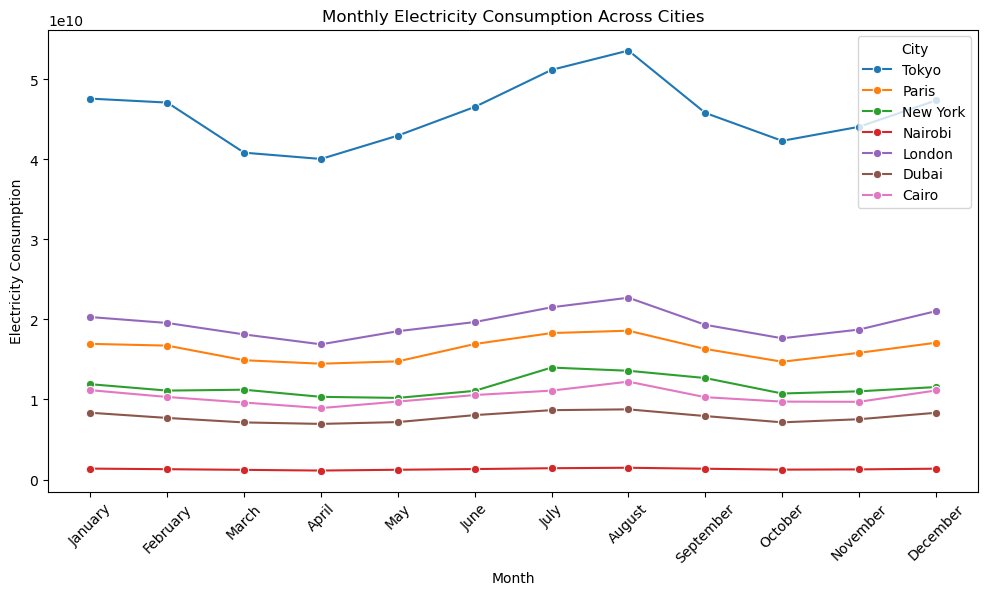

In [3]:

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_data,
    x='Month',
    y='Electricity Consumption',
    hue='City',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Monthly Electricity Consumption Across Cities')
plt.xlabel('Month')
plt.ylabel('Electricity Consumption')
plt.show()


## Visualization 2: Monthly Temperature Changes

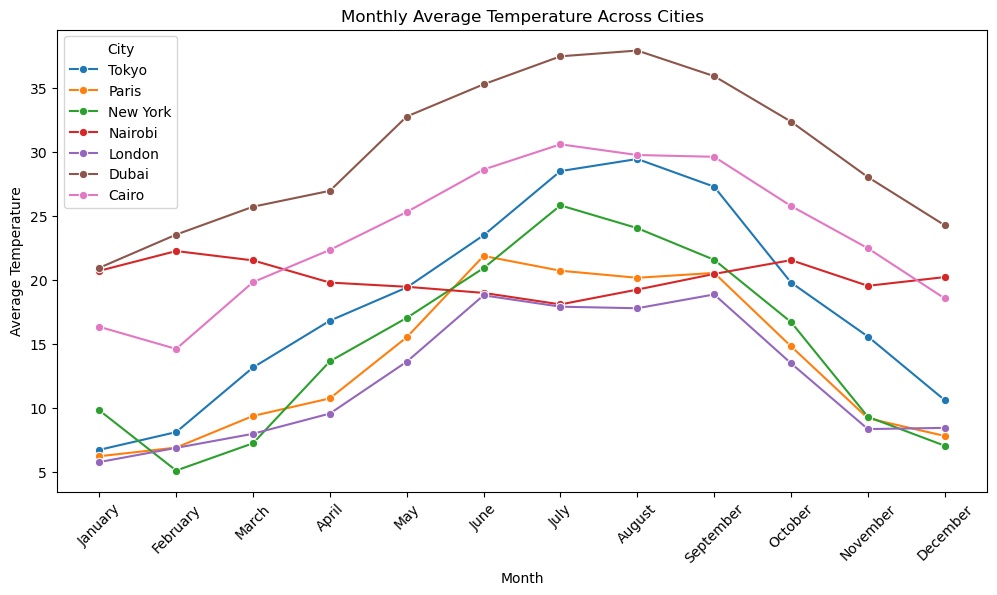

In [4]:

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_data,
    x='Month',
    y='Temperature_mean',
    hue='City',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Monthly Average Temperature Across Cities')
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.show()


## Visualization 3: Temperature vs Electricity Consumption

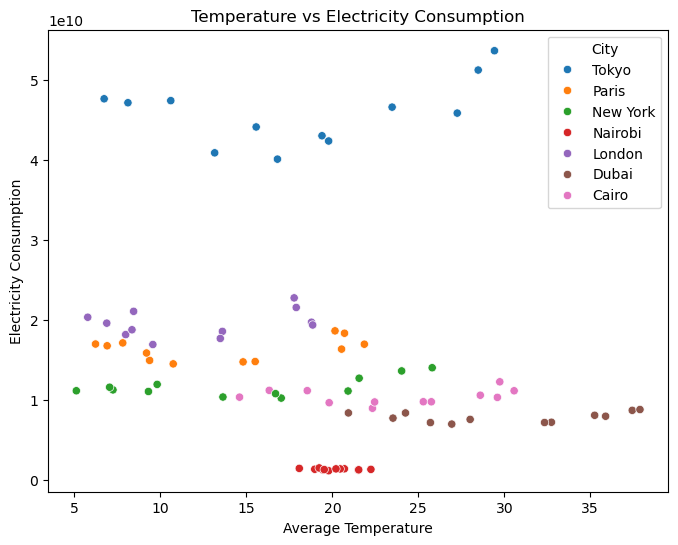

In [5]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=monthly_data,
    x='Temperature_mean',
    y='Electricity Consumption',
    hue='City'
)

plt.title('Temperature vs Electricity Consumption')
plt.xlabel('Average Temperature')
plt.ylabel('Electricity Consumption')
plt.show()


## Visualization 4: Monthly Temperature and Electricity Consumption Trend

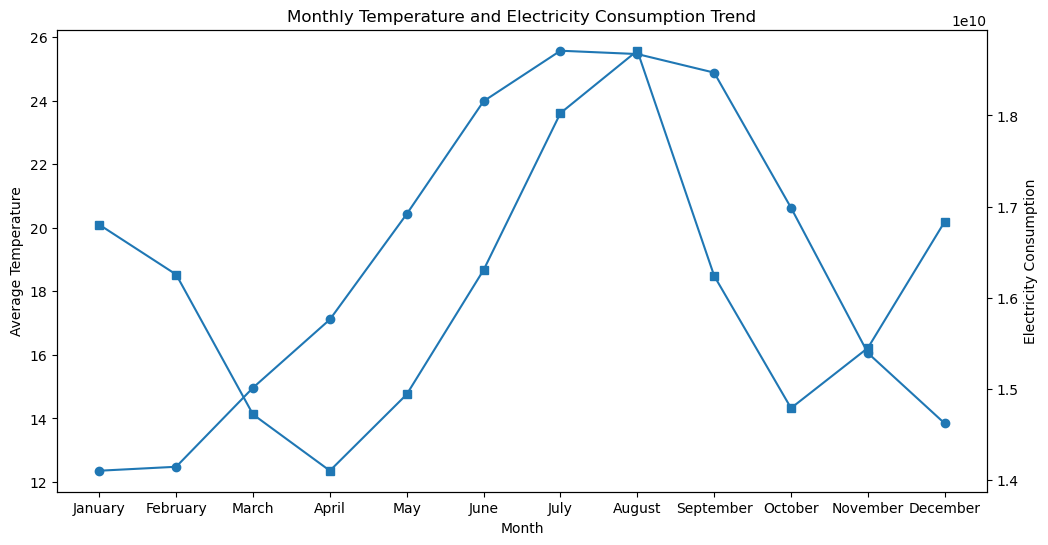

In [9]:

monthly_avg = monthly_data.groupby(
    'Month',
    observed=False
)[['Temperature_mean', 'Electricity Consumption']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(monthly_avg['Month'], monthly_avg['Temperature_mean'], marker='o')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Temperature')

ax2 = ax1.twinx()
ax2.plot(monthly_avg['Month'], monthly_avg['Electricity Consumption'], marker='s')
ax2.set_ylabel('Electricity Consumption')

plt.title('Monthly Temperature and Electricity Consumption Trend')
plt.xticks(rotation=45)
plt.show()


## Visualization 5: Correlation Heatmap

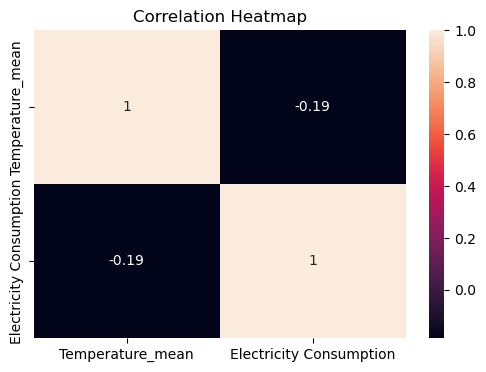

In [7]:

plt.figure(figsize=(6,4))

sns.heatmap(
    monthly_data[['Temperature_mean', 'Electricity Consumption']].corr(),
    annot=True
)

plt.title('Correlation Heatmap')
plt.show()


## Correlation Analysis

In [8]:

correlation = monthly_data['Temperature_mean'].corr(monthly_data['Electricity Consumption'])

print("Correlation between Temperature and Electricity Consumption:")
print(correlation)


Correlation between Temperature and Electricity Consumption:
-0.18623927732177423



## Insights

- Electricity consumption changes across different months in all cities.
- Higher temperatures during warmer months are generally associated with higher electricity consumption due to increased cooling demand.
- Temperature patterns differ between cities depending on climate conditions.
- The scatter plot and correlation analysis indicate a noticeable relationship between temperature and electricity consumption.
- Seasonal changes play an important role in electricity usage patterns across cities.
- The monthly trend visualization clearly shows how electricity usage changes alongside temperature fluctuations over the year.
